In [7]:
# Experiment 15: Iris Classification using Naive Bayes

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
# Dataset
iris = load_iris()

data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

data['Species'] = iris.target

print("Iris Dataset:")
print(data.head())

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GaussianNB()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

sample = [[5.1, 3.5, 1.4, 0.2]]
prediction = model.predict(sample)

print("\nPredicted Flower:",
      iris.target_names[prediction[0]])

Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Accuracy: 0.9777777777777777

Confusion Matrix:
[[19  0  0]
 [ 0 12  1]
 [ 0  0 13]]

Predicted Flower: setosa


Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Algorithm Performance:
Logistic Regression : 100.0 %
KNN : 100.0 %
Decision Tree : 100.0 %
Naive Bayes : 97.78 %
SVM : 100.0 %


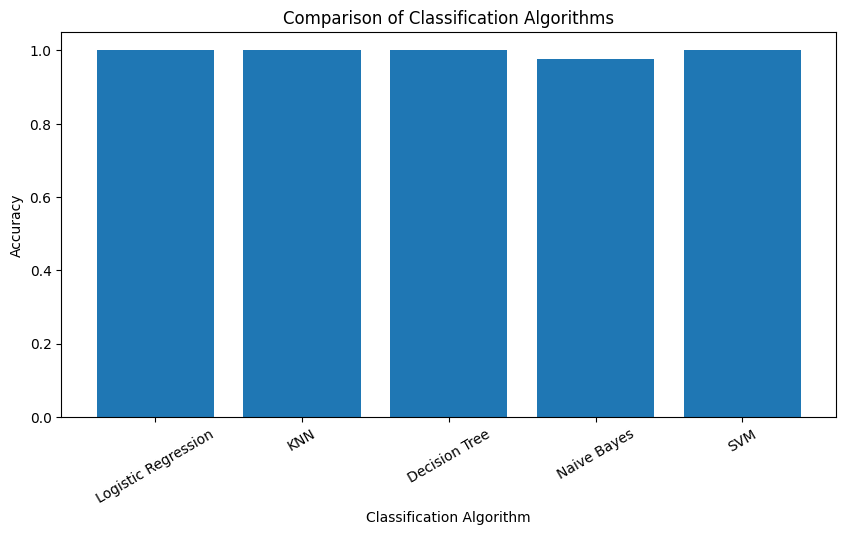

In [8]:
# Experiment 16: Classification Algorithm Comparison

import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split

from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC

from sklearn.metrics import accuracy_score

# Dataset
iris = load_iris()

data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

data['Species'] = iris.target

print("Dataset:")
print(data.head())

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

models = {
    'Logistic Regression': LogisticRegression(max_iter=200),
    'KNN': KNeighborsClassifier(n_neighbors=5),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Naive Bayes': GaussianNB(),
    'SVM': SVC()
}

results = {}

for name, model in models.items():

    model.fit(X_train, y_train)

    y_pred = model.predict(X_test)

    accuracy = accuracy_score(y_test, y_pred)

    results[name] = accuracy

print("\nAlgorithm Performance:")

for name, accuracy in results.items():
    print(name, ":", round(accuracy * 100, 2), "%")

# Graph
plt.figure(figsize=(10, 5))
plt.bar(results.keys(), results.values())
plt.ylabel("Accuracy")
plt.xlabel("Classification Algorithm")
plt.title("Comparison of Classification Algorithms")
plt.xticks(rotation=30)
plt.show()

In [9]:
# Experiment 17: Mobile Price Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report
import warnings
warnings.filterwarnings("ignore")
# Dataset
data = pd.DataFrame({
    'RAM': [2,2,3,3,4,4,6,6,8,8,12,12,4,6,8,3,2,8],
    'Storage': [32,64,32,64,64,128,128,256,128,256,256,512,
                64,128,256,32,32,128],
    'Battery': [3000,3500,4000,4500,4000,4500,5000,5000,4500,
                5000,5000,6000,4000,4500,5000,3500,3000,5000],
    'Camera': [8,12,12,16,16,32,48,64,48,64,108,108,16,48,64,12,8,50],
    'Price_Range': [
        'Low','Low','Low','Medium','Medium','Medium',
        'High','High','High','High','Premium','Premium',
        'Medium','High','Premium','Low','Low','High'
    ]
})

print("Mobile Dataset:")
print(data)

X = data[['RAM', 'Storage', 'Battery', 'Camera']]
y = data['Price_Range']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nAccuracy:", accuracy_score(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(
    y_test, y_pred, zero_division=0
))

# Prediction
mobile = [[8, 256, 5000, 64]]

print("\nPredicted Mobile Price Range:",
      model.predict(mobile)[0])

Mobile Dataset:
    RAM  Storage  Battery  Camera Price_Range
0     2       32     3000       8         Low
1     2       64     3500      12         Low
2     3       32     4000      12         Low
3     3       64     4500      16      Medium
4     4       64     4000      16      Medium
5     4      128     4500      32      Medium
6     6      128     5000      48        High
7     6      256     5000      64        High
8     8      128     4500      48        High
9     8      256     5000      64        High
10   12      256     5000     108     Premium
11   12      512     6000     108     Premium
12    4       64     4000      16      Medium
13    6      128     4500      48        High
14    8      256     5000      64     Premium
15    3       32     3500      12         Low
16    2       32     3000       8         Low
17    8      128     5000      50        High

Accuracy: 1.0

Classification Report:
              precision    recall  f1-score   support

        High    

In [10]:
# Experiment 18: Perceptron based Iris Classification

import pandas as pd
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Perceptron
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
# Dataset
iris = load_iris()

data = pd.DataFrame(
    iris.data,
    columns=iris.feature_names
)

data['Species'] = iris.target

print("Iris Dataset:")
print(data.head())

X = iris.data
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = Perceptron(max_iter=1000, random_state=42)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

print("\nActual Values:")
print(y_test)

print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Iris Dataset:
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

   Species  
0        0  
1        0  
2        0  
3        0  
4        0  

Predicted Values:
[0 0 2 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0]

Actual Values:
[1 0 2 1 1 0 1 2 1 1 2 0 0 0 0 1 2 1 1 2 0 2 0 2 2 2 2 2 0 0 0 0 1 0 0 2 1
 0 0 0 2 1 1 0 0]

Accuracy: 0.4666666666666667

Confusion Matrix:
[[19  0  0]
 [12  1  0]
 [11  1  1]]


In [11]:
# Experiment 19: Naive Bayes Bank Loan Prediction

import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, confusion_matrix
import warnings
warnings.filterwarnings("ignore")
# Dataset
data = pd.DataFrame({
    'Age': [22,25,28,30,35,40,45,50,55,60,27,32,38,48,52,29,42,57],
    'Income': [20,25,30,35,45,50,60,70,80,90,28,40,48,65,75,32,55,85],
    'Credit_Score': [550,580,600,620,650,680,700,720,740,760,
                     590,630,660,710,730,610,690,750],
    'Loan_Amount': [10,12,15,15,20,25,30,35,40,45,
                    12,18,22,32,38,15,28,42],
    'Loan_Approved': [
        0,0,0,0,1,1,1,1,1,1,
        0,1,1,1,1,0,1,1
    ]
})

print("Bank Loan Dataset:")
print(data)

X = data[['Age', 'Income', 'Credit_Score', 'Loan_Amount']]
y = data['Loan_Approved']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = GaussianNB()

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Values:")
print(y_pred)

print("\nActual Values:")
print(y_test.values)

print("\nAccuracy:",
      accuracy_score(y_test, y_pred))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred))

# New applicant
applicant = [[35, 50, 680, 25]]

prediction = model.predict(applicant)

print("\nLoan Approval Prediction:")

if prediction[0] == 1:
    print("Loan Approved")
else:
    print("Loan Not Approved")

Bank Loan Dataset:
    Age  Income  Credit_Score  Loan_Amount  Loan_Approved
0    22      20           550           10              0
1    25      25           580           12              0
2    28      30           600           15              0
3    30      35           620           15              0
4    35      45           650           20              1
5    40      50           680           25              1
6    45      60           700           30              1
7    50      70           720           35              1
8    55      80           740           40              1
9    60      90           760           45              1
10   27      28           590           12              0
11   32      40           630           18              1
12   38      48           660           22              1
13   48      65           710           32              1
14   52      75           730           38              1
15   29      32           610           15           

Sales Dataset:
    Month  Advertising  Previous_Sales  Sales
0       1           10             100    105
1       2           12             105    110
2       3           14             110    115
3       4           13             108    112
4       5           15             115    120
5       6           18             120    126
6       7           20             125    130
7       8           19             123    128
8       9           22             130    137
9      10           24             135    142
10     11           25             140    148
11     12           27             145    152
12     13           30             150    158
13     14           28             148    155
14     15           32             155    163
15     16           35             160    170
16     17           34             165    174
17     18           38             170    180
18     19           40             175    187
19     20           42             180    195

Predicted Sales:
[

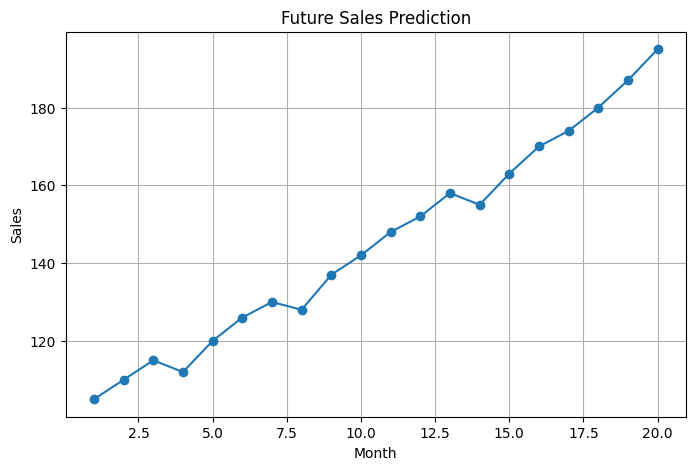

In [12]:
# Experiment 20: Future Sales Prediction

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
import warnings
warnings.filterwarnings("ignore")
# Dataset
data = pd.DataFrame({
    'Month': list(range(1, 21)),
    'Advertising': [
        10,12,14,13,15,18,20,19,22,24,
        25,27,30,28,32,35,34,38,40,42
    ],
    'Previous_Sales': [
        100,105,110,108,115,120,125,123,130,135,
        140,145,150,148,155,160,165,170,175,180
    ],
    'Sales': [
        105,110,115,112,120,126,130,128,137,142,
        148,152,158,155,163,170,174,180,187,195
    ]
})

print("Sales Dataset:")
print(data)

X = data[['Month', 'Advertising', 'Previous_Sales']]
y = data['Sales']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

print("\nPredicted Sales:")
print(y_pred)

print("\nR2 Score:",
      r2_score(y_test, y_pred))

print("Mean Squared Error:",
      mean_squared_error(y_test, y_pred))

# Future month prediction
future_month = [[21, 45, 195]]

prediction = model.predict(future_month)

print("\nPredicted Sales for Month 21:",
      round(prediction[0], 2))

# Plot actual sales
plt.figure(figsize=(8, 5))
plt.plot(data['Month'], data['Sales'], marker='o')
plt.xlabel("Month")
plt.ylabel("Sales")
plt.title("Future Sales Prediction")
plt.grid()
plt.show()